In [106]:
#!pip install pyarrow
#!pip install mlflow

     ---------------------------------------- 19.7/19.7 MB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 44.0/44.0 kB 2.1 MB/s eta 0:00:00
     -------------------------------------- 133.2/133.2 kB 7.7 MB/s eta 0:00:00
     -------------------------------------- 413.4/413.4 kB 1.4 MB/s eta 0:00:00
     -------------------------------------- 147.6/147.6 kB 2.2 MB/s eta 0:00:00
     -------------------------------------- 128.2/128.2 kB 3.8 MB/s eta 0:00:00
     ---------------------------------------- 56.7/56.7 kB 2.9 MB/s eta 0:00:00
     -------------------------------------- 233.4/233.4 kB 3.6 MB/s eta 0:00:00
     -------------------------------------- 207.3/207.3 kB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 78.8/78.8 kB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 9.3/9.3 MB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 62.7/62.7 kB 3.5 MB/s eta 0:00:00
     -------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-project 0.11.1 requires ruamel-yaml, which is not installed.


In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import os
import mlflow
import mlflow.sklearn

In [122]:
os.environ['MLFLOW_TRACKING_URI'] = 'sqlite:///mlflow.db'

In [123]:
df = pd.read_parquet('C://Users//fante//Desktop//PD1//Modelo//datosProcesados.parquet')

In [124]:
print(df.head())

     Marca   Modelo  Precio(€)              Adicional Primera matriculación  \
0  Peugeot     3008      17899    1.2 PureTech Allure            2019-12-27   
1  Renault   Captur      16999         1.3 TCe Intens            2020-10-27   
2      BMW  Serie 2      14799                   218d            2014-12-29   
3     Fiat     500X      13499  1.6 E-Torq City Cross            2018-07-17   
4      BMW  Serie 1      16799           116i M Sport            2018-06-27   

   Kilometraje(Km) Carburante Transmisión  Potencia(Cv)   Tracción  \
0            54616   Gasolina      manual           130  delantera   
1            32383   Gasolina      manual           131  delantera   
2           117846     Diésel      manual           143    trasera   
3            50914   Gasolina      manual           110  delantera   
4            66438   Gasolina      manual           110    trasera   

   Cilindrada(Cc) Accidentado  Edad(Meses)  
0            1199          No           51  
1            1

In [125]:
df.shape

(1810, 13)

In [126]:
df.columns

Index(['Marca', 'Modelo', 'Precio(€)', 'Adicional', 'Primera matriculación',
       'Kilometraje(Km)', 'Carburante', 'Transmisión', 'Potencia(Cv)',
       'Tracción', 'Cilindrada(Cc)', 'Accidentado', 'Edad(Meses)'],
      dtype='object')

In [127]:
X_df = df.drop(columns=['Precio(€)','Adicional','Primera matriculación','Accidentado'])
Y_df = df[['Precio(€)']]

In [128]:
X_df = pd.get_dummies(X_df, columns=['Marca','Modelo','Carburante','Transmisión','Tracción'])

In [129]:
X = X_df.to_numpy()
Y = Y_df.to_numpy()

In [130]:
np.mean(Y), np.median(Y)

(15374.947513812154, 13899.0)

In [131]:
RANDOM_STATE = 42
# Partimos el conjunto de datos en entrenamiento (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=RANDOM_STATE)

In [132]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import randint

# Crear el modelo de Random Forest
regressor = RandomForestRegressor(random_state=RANDOM_STATE)
    
 # Definir el rango de valores de n_estimators y max_leaf_nodes a probar para la búsqueda en cuadrícula
param_grid_grid_search = {
    'n_estimators': [50, 100, 150, 200],  
    'max_leaf_nodes': [None, 10, 20, 30]  
}

# Definir el rango de valores de n_estimators y max_leaf_nodes a probar para la búsqueda aleatoria
param_dist_random_search = {
    'n_estimators': randint(50, 200),
    'max_leaf_nodes': [None, 10, 20, 30]
}

# Inicializar GridSearchCV con el modelo, el espacio de búsqueda y la métrica de evaluación
grid_search = GridSearchCV(regressor, param_grid_grid_search, cv=5, scoring='neg_mean_absolute_error')

# Inicializar RandomizedSearchCV con el modelo, el espacio de búsqueda y la métrica de evaluación
random_search = RandomizedSearchCV(regressor, param_dist_random_search, cv=5, scoring='neg_mean_absolute_error', n_iter=10)

# Iniciar una ejecución de MLflow para la búsqueda en cuadrícula
with mlflow.start_run(run_name="GridSearchCV"):

    # Realizar la búsqueda en cuadrícula en los datos de entrenamiento
    grid_search.fit(X_train, y_train.ravel())

    # Obtener los mejores hiperparámetros de la búsqueda en cuadrícula
    best_params_grid_search = grid_search.best_params_

    # Extraer los valores de los hiperparámetros
    n_estimators_grid_search = best_params_grid_search['n_estimators']
    max_leaf_nodes_grid_search = best_params_grid_search['max_leaf_nodes']

    # Crear el modelo de Random Forest con los mejores hiperparámetros de la búsqueda en cuadrícula
    rand_forest_best_grid_search = RandomForestRegressor(n_estimators=n_estimators_grid_search, max_leaf_nodes=max_leaf_nodes_grid_search, random_state=RANDOM_STATE)

    # Entrenar el modelo con los datos de entrenamiento
    rand_forest_best_grid_search.fit(X_train, y_train.ravel())

    # Realizar predicciones con el mejor modelo de la búsqueda en cuadrícula
    predicciones_randF_G = rand_forest_best_grid_search.predict(X_test)

    # Calcular el error de prueba utilizando el MAE para el modelo con los mejores parámetros de GridSearch
    mae_RF_G = mean_absolute_error(y_test, predicciones_randF_G)
    print("MAE del mejor modelo de GridSearchCV:", mae_RF_G)

    # Registrar los parámetros y métricas en MLflow
    mlflow.log_params(best_params_grid_search)
    mlflow.log_metric("MAE", mae_RF_G)

# Iniciar una ejecución de MLflow para la búsqueda aleatoria
with mlflow.start_run(run_name="RandomizedSearchCV"):
    # Realizar la búsqueda aleatoria en los datos de entrenamiento
    random_search.fit(X_train, y_train.ravel())

    # Obtener los mejores hiperparámetros de la búsqueda aleatoria
    best_params_random_search = random_search.best_params_

    # Extraer los valores de los hiperparámetros
    n_estimators_random_search = best_params_random_search['n_estimators']
    max_leaf_nodes_random_search = best_params_random_search['max_leaf_nodes']

    # Crear el modelo de Random Forest con los mejores hiperparámetros de la búsqueda aleatoria
    rand_forest_best_random_search = RandomForestRegressor(n_estimators=n_estimators_random_search, max_leaf_nodes=max_leaf_nodes_random_search, random_state=RANDOM_STATE)

    # Entrenar el modelo con los datos de entrenamiento
    rand_forest_best_random_search.fit(X_train, y_train.ravel())

    # Realizar predicciones con el mejor modelo de la búsqueda aleatoria
    predicciones_randF_S = rand_forest_best_random_search.predict(X_test)

    # Calcular el error de prueba utilizando el MAE para el modelo con los mejores parámetros de RandomizedSearch
    mae_RF_S = mean_absolute_error(y_test, predicciones_randF_S)
    print("MAE del mejor modelo de RandomizedSearchCV:", mae_RF_S)

    # Registrar los parámetros y métricas en MLflow
    mlflow.log_params(best_params_random_search)
    mlflow.log_metric("MAE", mae_RF_S)

MAE del mejor modelo de GridSearchCV: 1518.5257090239413
MAE del mejor modelo de RandomizedSearchCV: 1516.3070641787415


In [133]:
#Metricas GridSearch
from sklearn.metrics import mean_squared_error, r2_score

# Calcular el error cuadrático medio (MSE)
mse_RF_G = mean_squared_error(y_test, predicciones_randF_G)

# Calcular la raíz del error cuadrático medio (RMSE)
rmse_RF_G = np.sqrt(mse_RF_G)

# Calcular el coeficiente de determinación (R²)
r2_RF_G = r2_score(y_test, predicciones_randF_G)

print("MAE:", mae_RF_G)
print("MSE:", mse_RF_G)
print("RMSE:", rmse_RF_G)
print("R²:", r2_RF_G)

MAE: 1518.5257090239413
MSE: 5180591.930952762
RMSE: 2276.0913713980735
R²: 0.8428544917280436


In [134]:
#Metricas RandomSearch
from sklearn.metrics import mean_squared_error, r2_score

# Calcular el error cuadrático medio (MSE)
mse_RF_S = mean_squared_error(y_test, predicciones_randF_S)

# Calcular la raíz del error cuadrático medio (RMSE)
rmse_RF_S = np.sqrt(mse_RF_S)

# Calcular el coeficiente de determinación (R²)
r2_RF_S = r2_score(y_test, predicciones_randF_S)

print("MAE:", mae_RF_S)
print("MSE:", mse_RF_S)
print("RMSE:", rmse_RF_S)
print("R²:", r2_RF_S)

MAE: 1516.3070641787415
MSE: 5132138.002117962
RMSE: 2265.4222569132585
R²: 0.8443242691928589


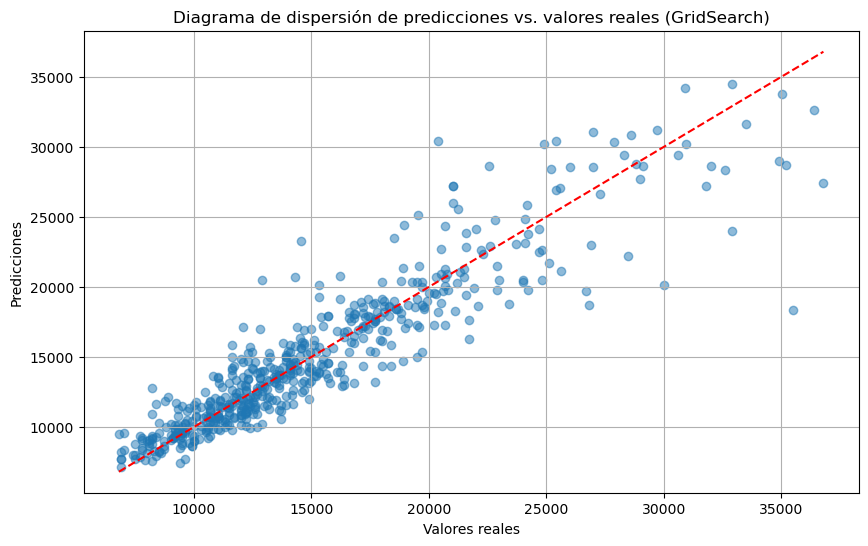

In [135]:
import matplotlib.pyplot as plt

# Diagrama de dispersión de predicciones vs. valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predicciones_randF_G, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Diagrama de dispersión de predicciones vs. valores reales (GridSearch)')
plt.grid(True)
plt.show()

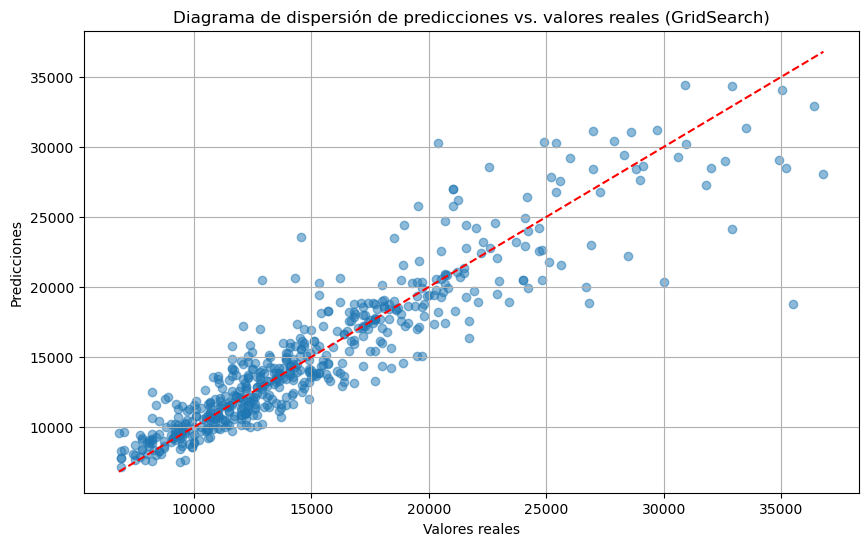

In [136]:
import matplotlib.pyplot as plt

# Diagrama de dispersión de predicciones vs. valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predicciones_randF_S, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Diagrama de dispersión de predicciones vs. valores reales (GridSearch)')
plt.grid(True)
plt.show()
